# 01 — Data Ingestion & Exploration

Reads every CSV in `data/raw/`, prints shape, dtypes, first 5 rows, missing values, and duplicate counts.

**Datasets**
| File | Description |
|------|-------------|
| 01_fund_master.csv | Scheme metadata (AMC, category, benchmark, expense ratio …) |
| 02_nav_history.csv | Daily NAV time-series per scheme (2022-01 → present) |
| 03_aum_by_fund_house.csv | Bi-annual AUM per AMC |
| 04_monthly_sip_inflows.csv | Industry-level SIP statistics |
| 05_category_inflows.csv | Monthly net inflows by equity / debt category |
| 06_industry_folio_count.csv | Quarterly total & type-wise folio counts |
| 07_scheme_performance.csv | Risk-return metrics per scheme |
| 08_investor_transactions.csv | Individual investor transaction ledger |
| 09_portfolio_holdings.csv | Equity holdings per scheme |
| 10_benchmark_indices.csv | NIFTY 50 daily close values |

## 1. Load & Profile Every CSV

In [1]:
import pandas as pd
from pathlib import Path

# Path to raw data folder
raw_path = Path("../data/raw")

# Read every CSV file
for file in sorted(raw_path.glob("*.csv")):
    print("\n" + "=" * 60)
    print(f"Dataset: {file.name}")
    try:
        df = pd.read_csv(file)
        print("\nShape:")
        print(df.shape)
        print("\nData Types:")
        print(df.dtypes)
        print("\nFirst 5 Rows:")
        print(df.head())
        print("\nMissing Values:")
        print(df.isnull().sum())
        print("\nDuplicate Rows:")
        print(df.duplicated().sum())
    except Exception as e:
        print(f"Error reading {file.name}")
        print(e)


Dataset: 01_fund_master.csv

Shape:
(40, 15)

Data Types:
amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

First 5 Rows:
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan 

---
## 2. Load Individual DataFrames for EDA

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

fund_master      = pd.read_csv(raw_path / "01_fund_master.csv")
nav_history      = pd.read_csv(raw_path / "02_nav_history.csv", parse_dates=["date"])
aum              = pd.read_csv(raw_path / "03_aum_by_fund_house.csv", parse_dates=["date"])
sip_inflows      = pd.read_csv(raw_path / "04_monthly_sip_inflows.csv", parse_dates=["month"])
cat_inflows      = pd.read_csv(raw_path / "05_category_inflows.csv", parse_dates=["month"])
folio_count      = pd.read_csv(raw_path / "06_industry_folio_count.csv", parse_dates=["month"])
performance      = pd.read_csv(raw_path / "07_scheme_performance.csv")
transactions     = pd.read_csv(raw_path / "08_investor_transactions.csv", parse_dates=["transaction_date"])
holdings         = pd.read_csv(raw_path / "09_portfolio_holdings.csv", parse_dates=["portfolio_date"])
benchmark        = pd.read_csv(raw_path / "10_benchmark_indices.csv", parse_dates=["date"])

print("All datasets loaded.")

All datasets loaded.


---
## 3. Fund Master — Scheme Distribution

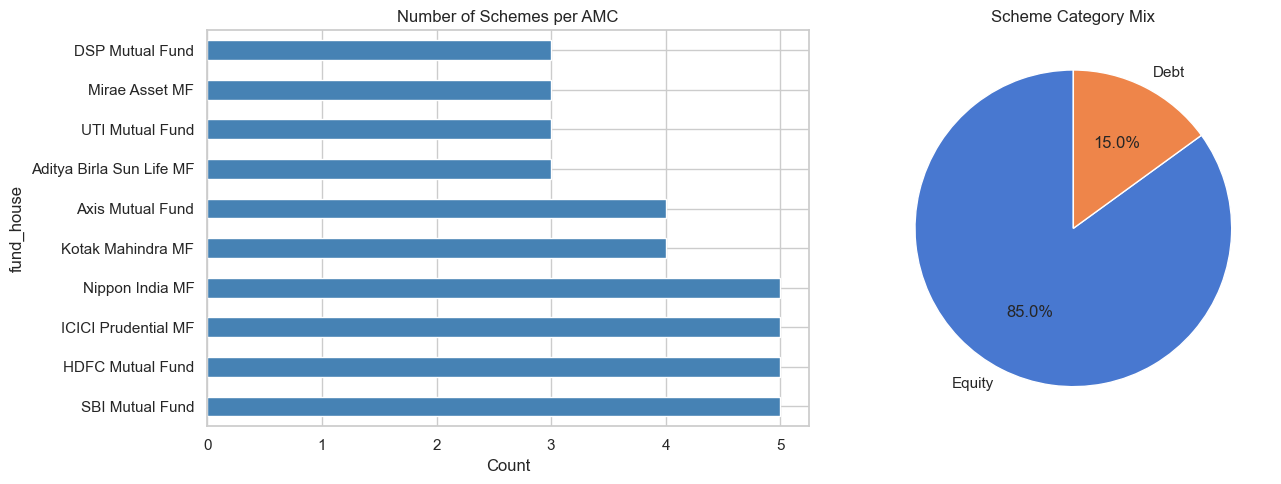

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Schemes per AMC
fund_master["fund_house"].value_counts().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Number of Schemes per AMC")
axes[0].set_xlabel("Count")

# Category distribution
fund_master["category"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Scheme Category Mix")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

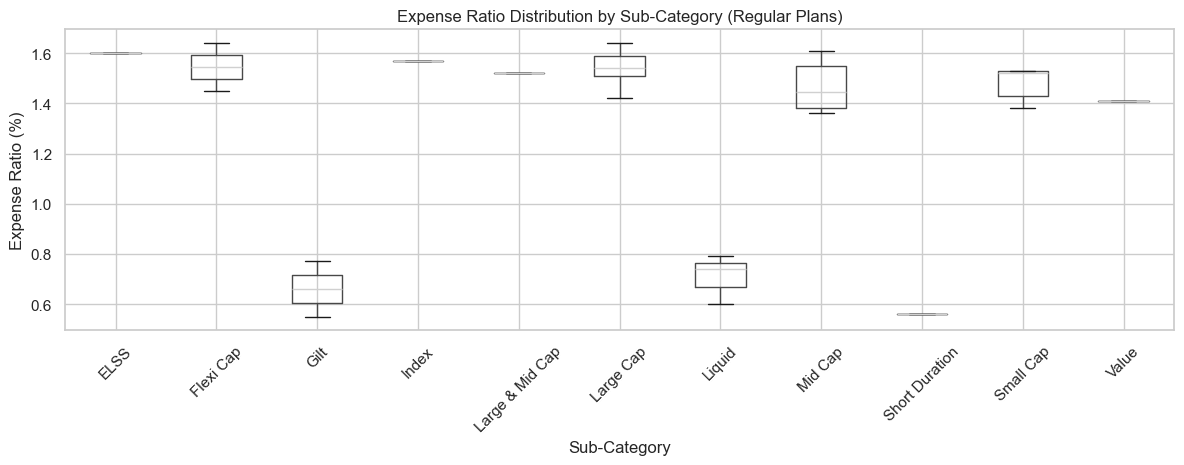

In [4]:
# Expense ratio by sub-category (regular plans only)
regular = fund_master[fund_master["plan"] == "Regular"]
fig, ax = plt.subplots(figsize=(12, 5))
regular.boxplot(column="expense_ratio_pct", by="sub_category", ax=ax, rot=45)
ax.set_title("Expense Ratio Distribution by Sub-Category (Regular Plans)")
ax.set_xlabel("Sub-Category")
ax.set_ylabel("Expense Ratio (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()

---
## 4. NAV History — Time-Series Analysis

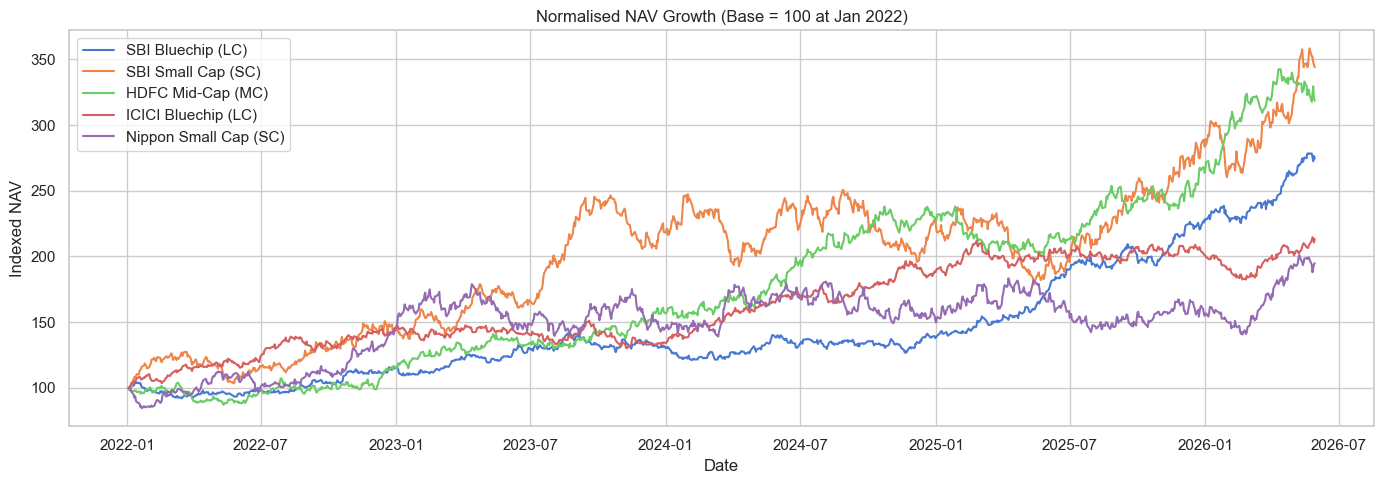

In [5]:
# Pick a representative set of schemes for visual clarity
sample_codes = [119551, 119598, 100033, 120503, 118634]
labels = {
    119551: "SBI Bluechip (LC)",
    119598: "SBI Small Cap (SC)",
    100033: "HDFC Mid-Cap (MC)",
    120503: "ICICI Bluechip (LC)",
    118634: "Nippon Small Cap (SC)",
}

fig, ax = plt.subplots(figsize=(14, 5))
for code in sample_codes:
    subset = nav_history[nav_history["amfi_code"] == code].sort_values("date")
    # Normalise to 100 at start for fair comparison
    normalised = subset["nav"] / subset["nav"].iloc[0] * 100
    ax.plot(subset["date"], normalised, label=labels[code])

ax.set_title("Normalised NAV Growth (Base = 100 at Jan 2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed NAV")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. AUM Growth by Fund House

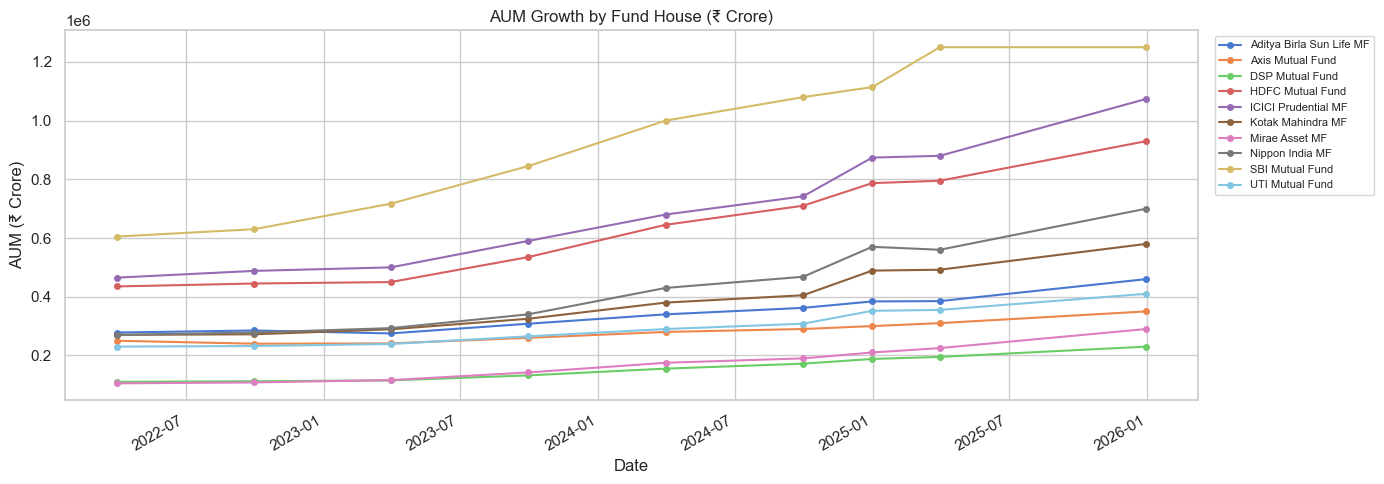

In [6]:
pivot_aum = aum.pivot_table(index="date", columns="fund_house", values="aum_crore")

fig, ax = plt.subplots(figsize=(14, 5))
pivot_aum.plot(ax=ax, marker="o", markersize=4)
ax.set_title("AUM Growth by Fund House (₹ Crore)")
ax.set_xlabel("Date")
ax.set_ylabel("AUM (₹ Crore)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. SIP Inflows — Industry Trend

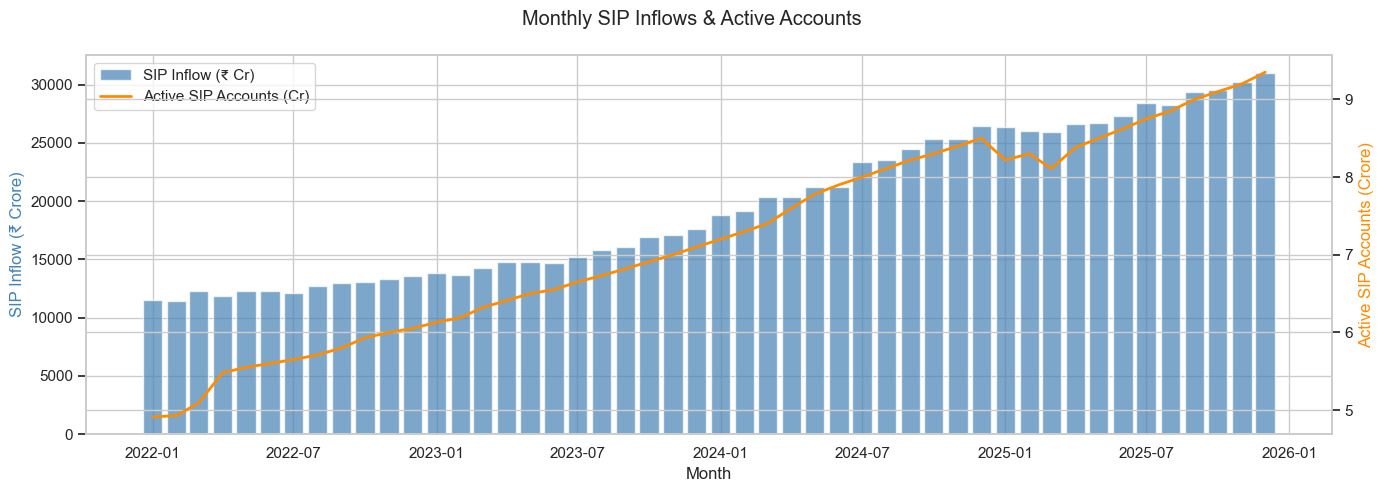

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(sip_inflows["month"], sip_inflows["sip_inflow_crore"],
        width=25, color="steelblue", alpha=0.7, label="SIP Inflow (₹ Cr)")
ax1.set_ylabel("SIP Inflow (₹ Crore)", color="steelblue")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(sip_inflows["month"], sip_inflows["active_sip_accounts_crore"],
         color="darkorange", linewidth=2, label="Active SIP Accounts (Cr)")
ax2.set_ylabel("Active SIP Accounts (Crore)", color="darkorange")

fig.suptitle("Monthly SIP Inflows & Active Accounts")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

---
## 7. Category Inflows — Heatmap

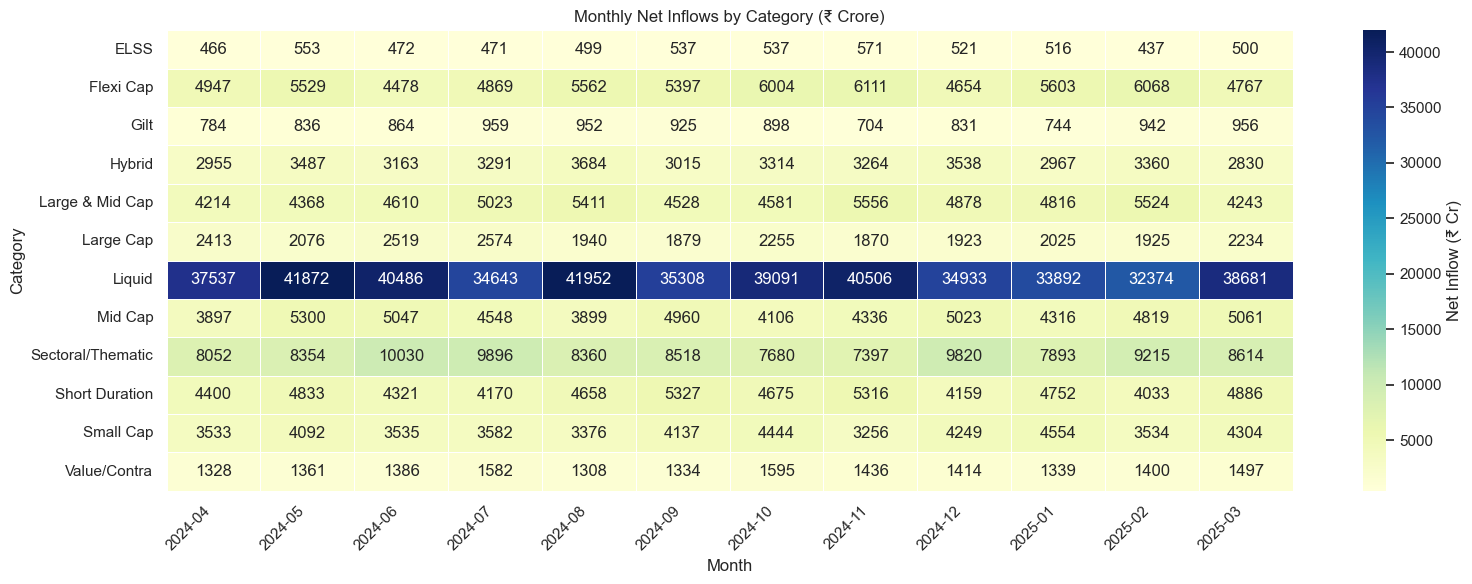

In [8]:
pivot_cat = cat_inflows.pivot_table(
    index="category", columns=cat_inflows["month"].dt.to_period("M").astype(str),
    values="net_inflow_crore"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_cat, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Net Inflow (₹ Cr)"})
ax.set_title("Monthly Net Inflows by Category (₹ Crore)")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 8. Scheme Performance — Risk vs Return

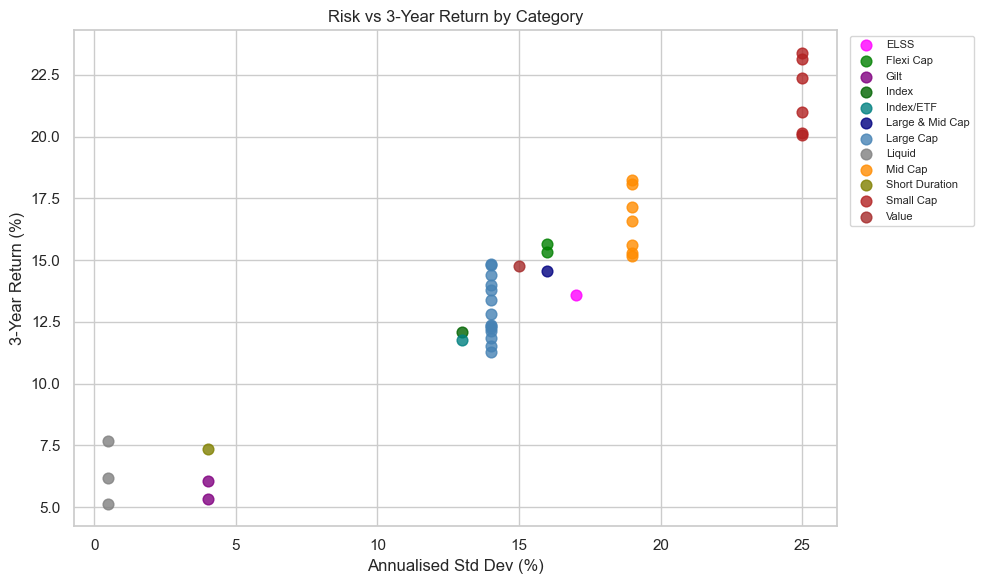

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Large Cap": "steelblue", "Mid Cap": "darkorange",
          "Small Cap": "firebrick", "Flexi Cap": "green",
          "Gilt": "purple", "Liquid": "gray",
          "Short Duration": "olive", "Index/ETF": "teal",
          "Value": "brown", "ELSS": "magenta",
          "Large & Mid Cap": "navy", "Index": "darkgreen"}

for cat, grp in performance.groupby("category"):
    ax.scatter(
        grp["std_dev_ann_pct"], grp["return_3yr_pct"],
        label=cat, color=colors.get(cat, "black"), s=60, alpha=0.8
    )

ax.set_title("Risk vs 3-Year Return by Category")
ax.set_xlabel("Annualised Std Dev (%)")
ax.set_ylabel("3-Year Return (%)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# Top 10 schemes by Sharpe ratio
top_sharpe = performance.nlargest(10, "sharpe_ratio")[["scheme_name", "category", "sharpe_ratio", "return_3yr_pct"]]
top_sharpe.style.background_gradient(subset=["sharpe_ratio"], cmap="Greens")

,scheme_name,category,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.680000,7.680000
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.180000,6.180000
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.140000,5.140000
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,1.840000,7.370000
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,1.520000,6.070000
19,Nippon India Gilt Securities Fund - Regular - Growth,Gilt,1.330000,5.310000
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.060000,14.840000
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.060000,14.810000
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.030000,14.410000
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,1.000000,14.000000


---
## 9. Investor Transactions — Behavioural Patterns

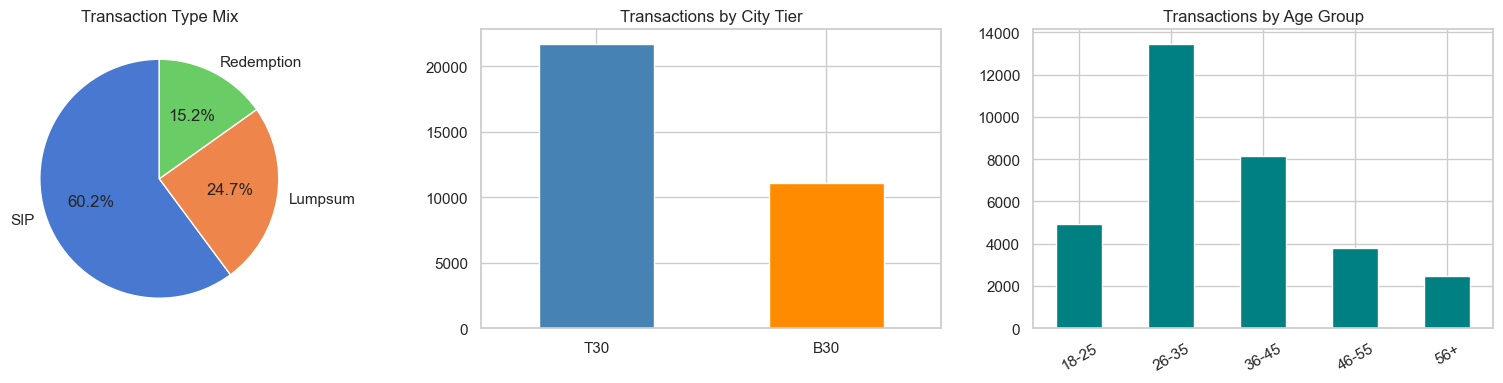

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Transaction type split
transactions["transaction_type"].value_counts().plot(
    kind="pie", ax=axes[0], autopct="%1.1f%%", startangle=90
)
axes[0].set_title("Transaction Type Mix")
axes[0].set_ylabel("")

# City tier split
transactions["city_tier"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue", "darkorange"]
)
axes[1].set_title("Transactions by City Tier")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

# Age group distribution
order = ["18-25", "26-35", "36-45", "46-55", "56+"]
transactions["age_group"].value_counts().reindex(order).plot(
    kind="bar", ax=axes[2], color="teal"
)
axes[2].set_title("Transactions by Age Group")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

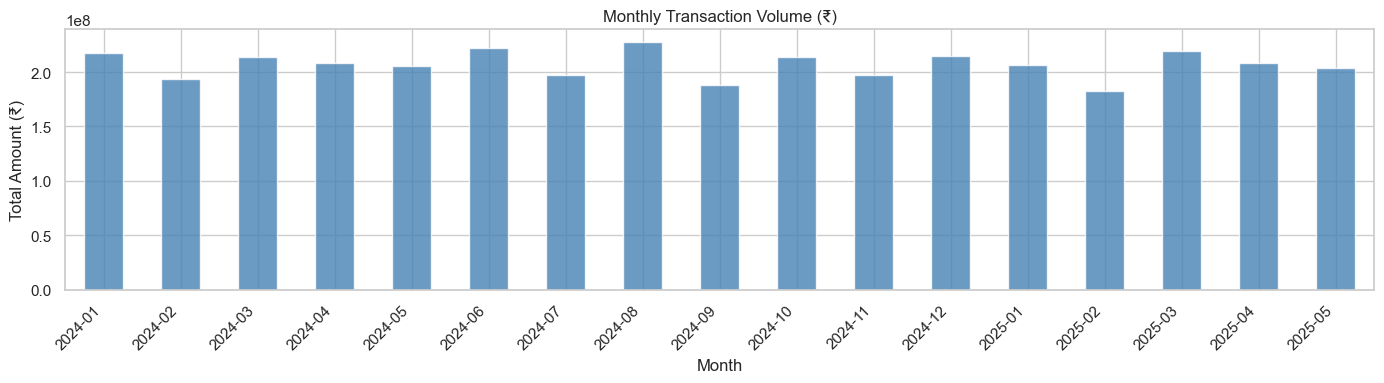

In [12]:
# Monthly transaction volume
txn_monthly = transactions.groupby(transactions["transaction_date"].dt.to_period("M"))["amount_inr"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
txn_monthly.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
ax.set_title("Monthly Transaction Volume (₹)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 10. Portfolio Holdings — Sector Exposure

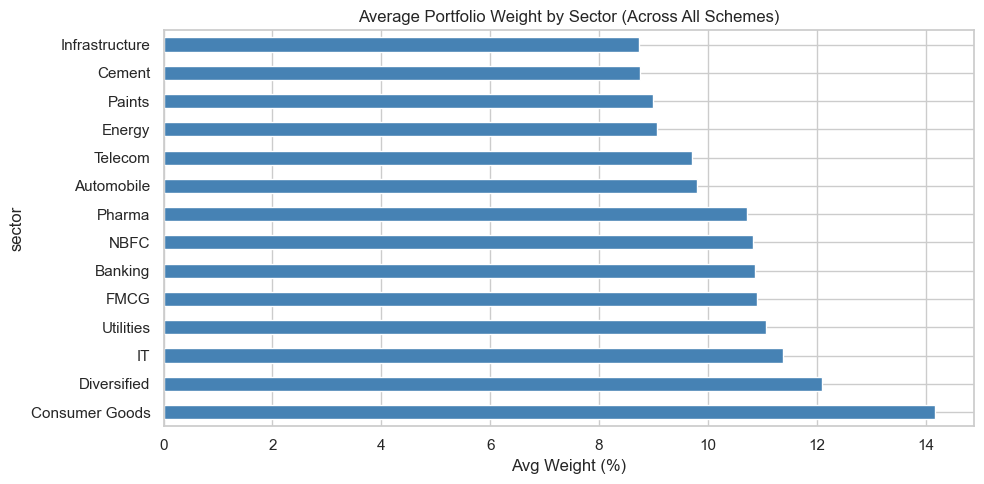

In [13]:
sector_exposure = (
    holdings.groupby("sector")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sector_exposure.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Average Portfolio Weight by Sector (Across All Schemes)")
ax.set_xlabel("Avg Weight (%)")
plt.tight_layout()
plt.show()

---
## 11. Benchmark — NIFTY 50 Trend

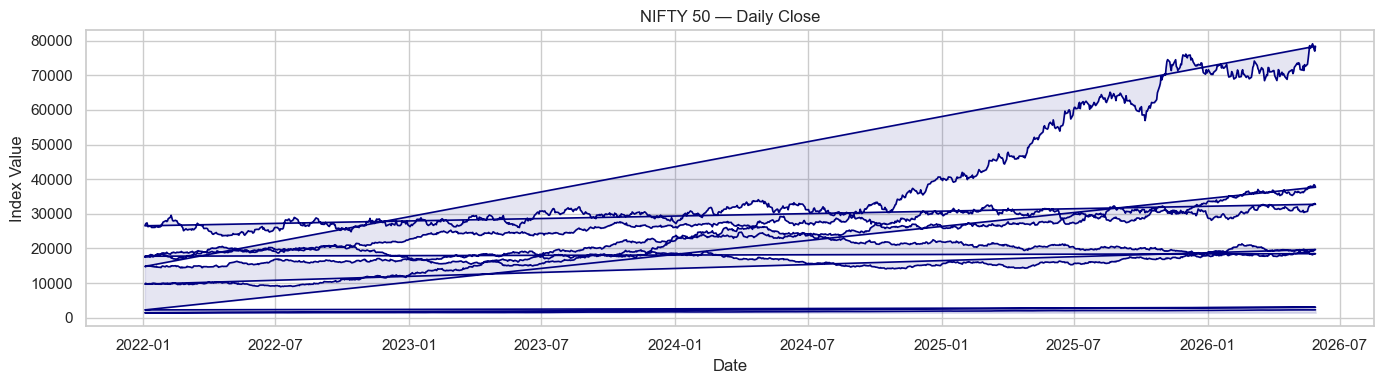

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(benchmark["date"], benchmark["close_value"], color="navy", linewidth=1.2)
ax.fill_between(benchmark["date"], benchmark["close_value"],
                benchmark["close_value"].min(), alpha=0.1, color="navy")
ax.set_title("NIFTY 50 — Daily Close")
ax.set_xlabel("Date")
ax.set_ylabel("Index Value")
plt.tight_layout()
plt.show()

---
## 12. Summary Statistics

In [15]:
summary = {
    "Total Schemes": len(fund_master),
    "AMCs": fund_master["fund_house"].nunique(),
    "NAV Records": len(nav_history),
    "Unique Scheme Codes (NAV)": nav_history["amfi_code"].nunique(),
    "Transaction Records": len(transactions),
    "Unique Investors": transactions["investor_id"].nunique(),
    "Transaction Date Range": f"{transactions['transaction_date'].min().date()} → {transactions['transaction_date'].max().date()}",
    "NAV Date Range": f"{nav_history['date'].min().date()} → {nav_history['date'].max().date()}",
}

for k, v in summary.items():
    print(f"{k:<35} {v}")

Total Schemes                       40
AMCs                                10
NAV Records                         46000
Unique Scheme Codes (NAV)           40
Transaction Records                 32778
Unique Investors                    5000
Transaction Date Range              2024-01-01 → 2025-05-30
NAV Date Range                      2022-01-03 → 2026-05-29
